# Retina layer sweep

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [2]:
dataset_name = 'retina'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/subref_signature_matrix_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/bulk2_id.csv'
ground_truth_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/ground_truth_batch2.csv'

# Sig mat
signature_df = pd.read_csv(reference_path, index_col=0)
signature_df = signature_df.T

# bulk data
bulk_df = pd.read_csv(bulk_path, index_col=0)
bulk_df = bulk_df.T
bulk_df = bulk_df.loc[bulk_df.index.dropna()]

# Ground truth
ground_truth = pd.read_csv(ground_truth_path, index_col=0)
ground_truth = ground_truth.T

In [3]:
signature_df.head()

author_cell_type,AC,BC,Cone,HC,NN,Rod
ENSG00000243485,0.000025,0.007665,0.011325,0.000035,0.00002,0.00548
ENSG00000237613,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000186092,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000239945,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
ENSG00000239906,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000


In [4]:
def harmonize_columns(df):
    df = df.copy()
    if 'RGC' in df.columns and 'MG' in df.columns:
        df['NN'] = df['RGC'] + df['MG']
        df = df.drop(columns=['RGC', 'MG'])
    return df

In [6]:
ground_truth = harmonize_columns(ground_truth)

### Zero Shot

In [7]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_zeroshot_retina.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 139.98it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:547: FutureWarning: Serie

Loading Geneformer model...


...

Loading Geneformer model...
Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 11.69.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1986.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9539.
Most similar pair: BC vs HC.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.01 seconds.
Running solver: simplex
Finished in 0.01 seconds.
Running solver: ridge_simplex
Finished in 0.01 seconds.
Running solver: dwls_simplex
Finished in 0.03 seconds.
Running solver: ridge
Finished in 0.02 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 0.48 seconds.
Running solver: simplex_nnls
Finished in 0.01 seconds.
Running solver: gradient_descent


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.29 seconds.


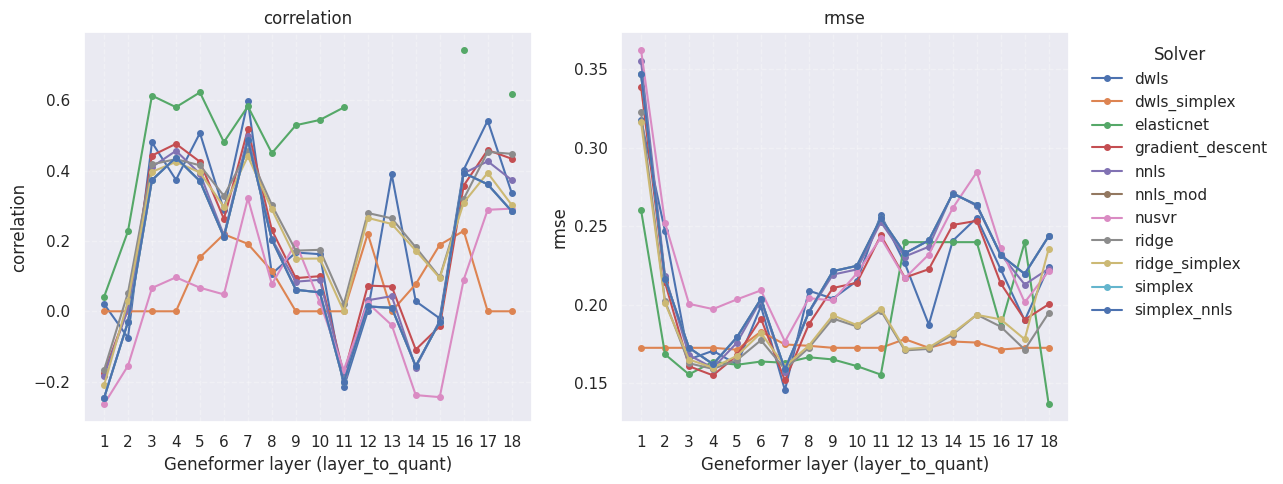

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
68       7              dwls     0.597129  0.145480         0.248801  0.138294
170     16      dwls_simplex     0.228599  0.171398         0.022428  0.149940
172     16        elasticnet     0.742777  0.186092        -0.145407  0.164641
76       7  gradient_descent     0.517399  0.151648         0.233200  0.137752
66       7              nnls     0.497132  0.157248         0.277342  0.145065
67       7          nnls_mod     0.486315  0.158677         0.277997  0.146059
74       7             nusvr     0.321273  0.176498         0.253121  0.159819
72       7             ridge     0.456067  0.158813         0.255279  0.144340
70       7     ridge_simplex     0.440681  0.160699         0.274251  0.145997
69       7           simplex     0.486313  0.158677         0.279199  0.146060
75       7      simplex_nnls     0.486315  0.158676         0.234093  0.146059


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_zeroshot_retina.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

### Fine-tuned

In [9]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/geneformer/complete/finetuned316m/260301_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/',
        model_path='/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/retina_ref1test2/geneformer/complete/finetuned316m/260301_geneformer_cellClassifier_cell_annot_subset/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_finetuned_retina.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 148.83it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/gf_temp/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:547: FutureWarning: Serie

Loading Geneformer model...


...

Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 2.28.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.7007.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.5046.
Most similar pair: Cone vs Rod.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.01 seconds.
Running solver: nnls_mod
Finished in 0.01 seconds.
Running solver: dwls
Finished in 0.03 seconds.
Running solver: simplex
Finished in 0.03 seconds.
Running solver: ridge_simplex
Finished in 0.03 seconds.
Running solver: dwls_simplex
Finished in 0.05 seconds.
Running solver: ridge
Finished in 0.03 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 0.68 seconds.
Running solver: simplex_nnls
Finished in 0.02 seconds.
Running solver: gradient_descent


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 17.14 seconds.


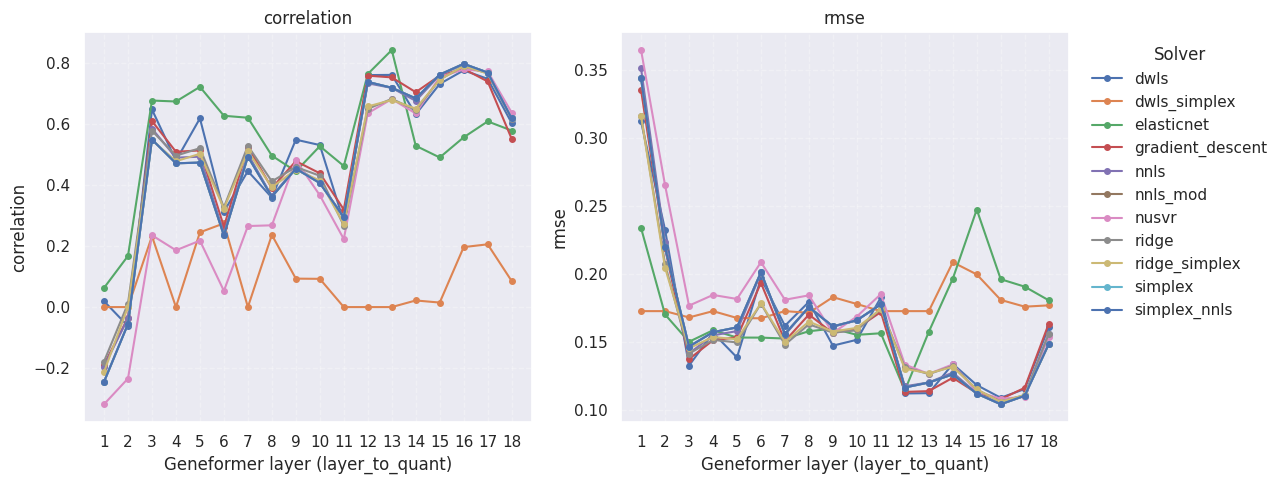

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
167     16              dwls     0.776452  0.108748         0.366181  0.097923
60       6      dwls_simplex     0.274638  0.167186         0.095582  0.142676
139     13        elasticnet     0.843080  0.157244         0.195240  0.134199
175     16  gradient_descent     0.781407  0.107714         0.397044  0.088900
165     16              nnls     0.796148  0.104368         0.365035  0.092960
166     16          nnls_mod     0.797923  0.103965         0.366408  0.092642
173     16             nusvr     0.779501  0.108038         0.337149  0.096175
171     16             ridge     0.789954  0.105847         0.358990  0.093258
169     16     ridge_simplex     0.790375  0.105693         0.358678  0.093212
168     16           simplex     0.797923  0.103965         0.366408  0.092642
174     16      simplex_nnls     0.797923  0.103965         0.366409  0.092642


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_finetuned_retina.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])